## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
url = "https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset"
#df = pd.read_html(url)

df=pd.read_csv('online_shoppers_intention.csv')

## Data Understanding

preview data

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Initial data checks

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

statistical summary

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


missing values check

In [6]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Feature Engineering

Convert Categorical Variables

ML models need numeric input

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Month'] = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


## Exploratory Data Analysis (EDA) 

#### Correlation Heatmap
Correlation Heatmap:

High correlation → possible multicollinearity

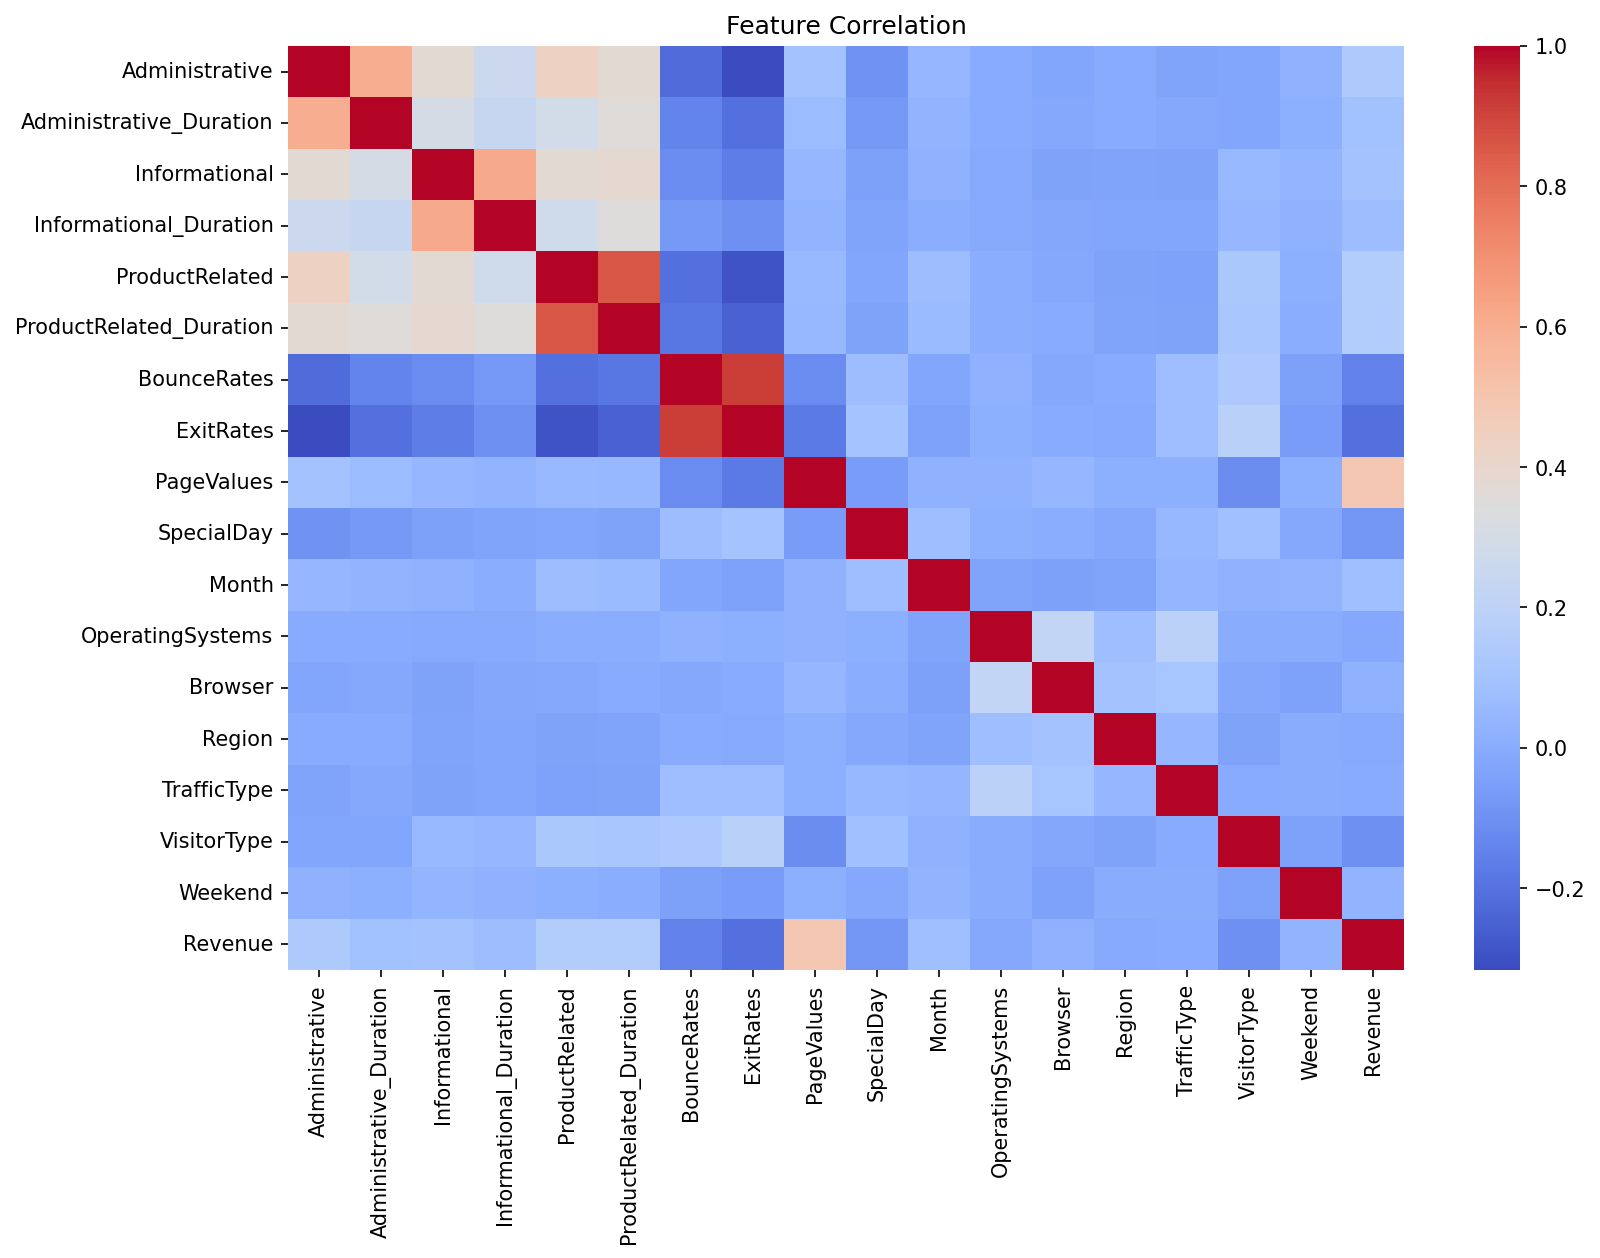

In [8]:
plt.figure(figsize=(12,8),dpi=150)
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

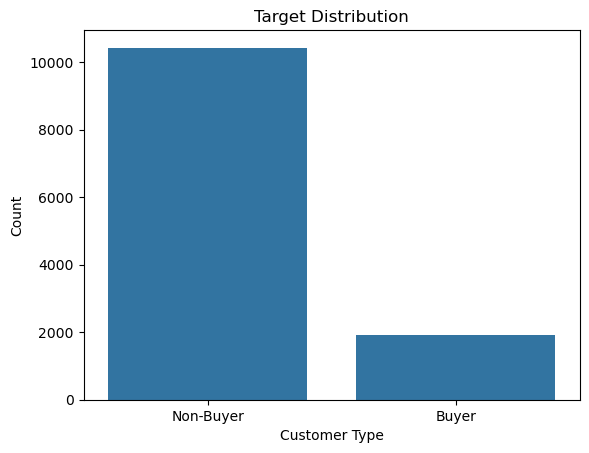

In [9]:
sns.countplot(x='Revenue', data=df)

plt.title('Target Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Buyer', 'Buyer'])
plt.show()

# Class imbalance present
# More non-buyers than buyers

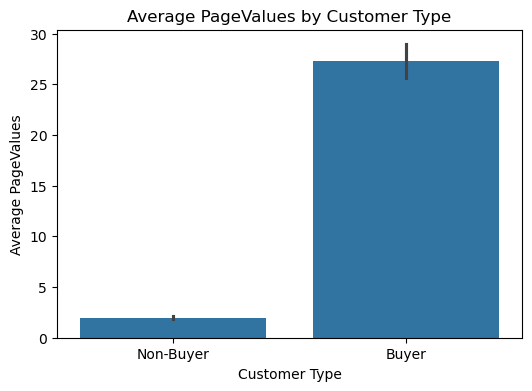

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(x='Revenue', y='PageValues', data=df)
plt.title('Average PageValues by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average PageValues')
plt.xticks([0,1], ['Non-Buyer', 'Buyer'])
plt.show()

# Buyers have much higher average PageValues than non-buyers

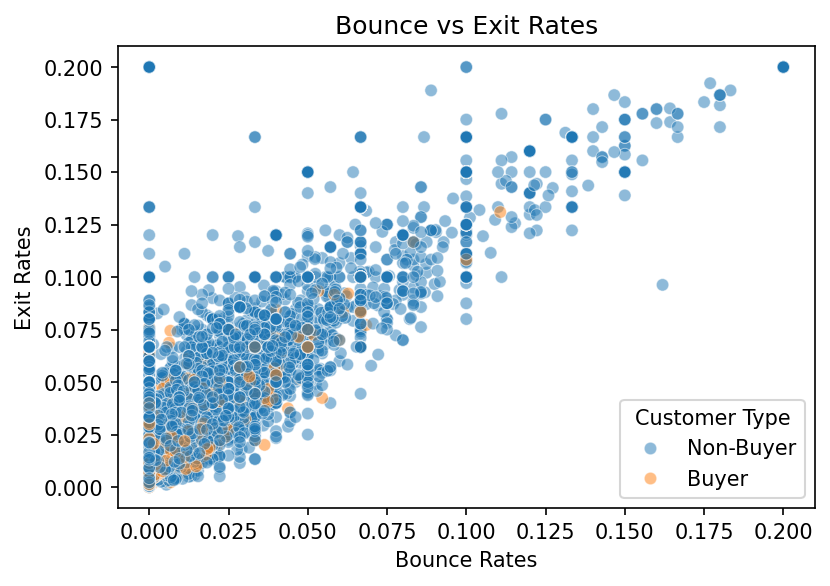

In [11]:
# need to Change label
df['Revenue_Label'] = df['Revenue'].map({0: 'Non-Buyer', 1: 'Buyer'})

plt.figure(figsize=(6,4), dpi=150)
sns.scatterplot(x='BounceRates', y='ExitRates', hue='Revenue_Label', alpha=0.5 ,data=df)

plt.title('Bounce vs Exit Rates')
plt.xlabel('Bounce Rates')
plt.ylabel('Exit Rates')

plt.legend(title='Customer Type')

plt.show()

# Users who leave quickly are unlikely to buy, while engaged users are more likely to convert.

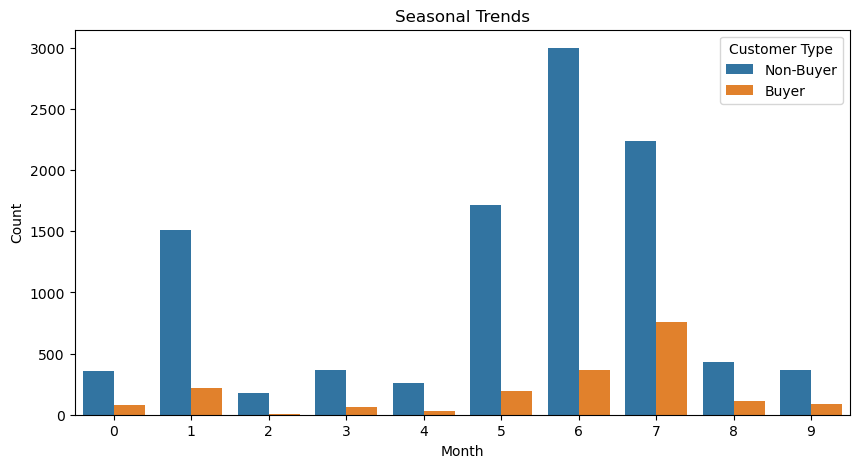

In [12]:
plt.figure(figsize=(10,5), dpi=100)
sns.countplot(x='Month', hue='Revenue', data=df, hue_order=[0, 1])
plt.title('Seasonal Trends')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title='Customer Type', labels=['Non-Buyer', 'Buyer'])
plt.show()

# June have highest Revenue generate.

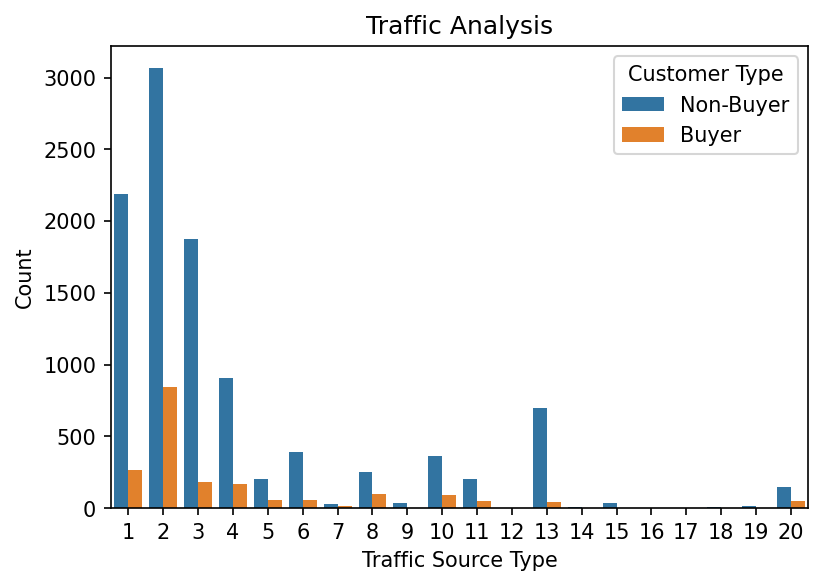

In [13]:
plt.figure(figsize=(6,4),dpi=150)
sns.countplot(x='TrafficType', hue='Revenue', data=df)
plt.title('Traffic Analysis')
plt.xlabel('Traffic Source Type')
plt.ylabel('Count')
plt.legend(title='Customer Type', labels=['Non-Buyer', 'Buyer'])
plt.show()

# Some traffic sources convert better

Feature Distribution Plot

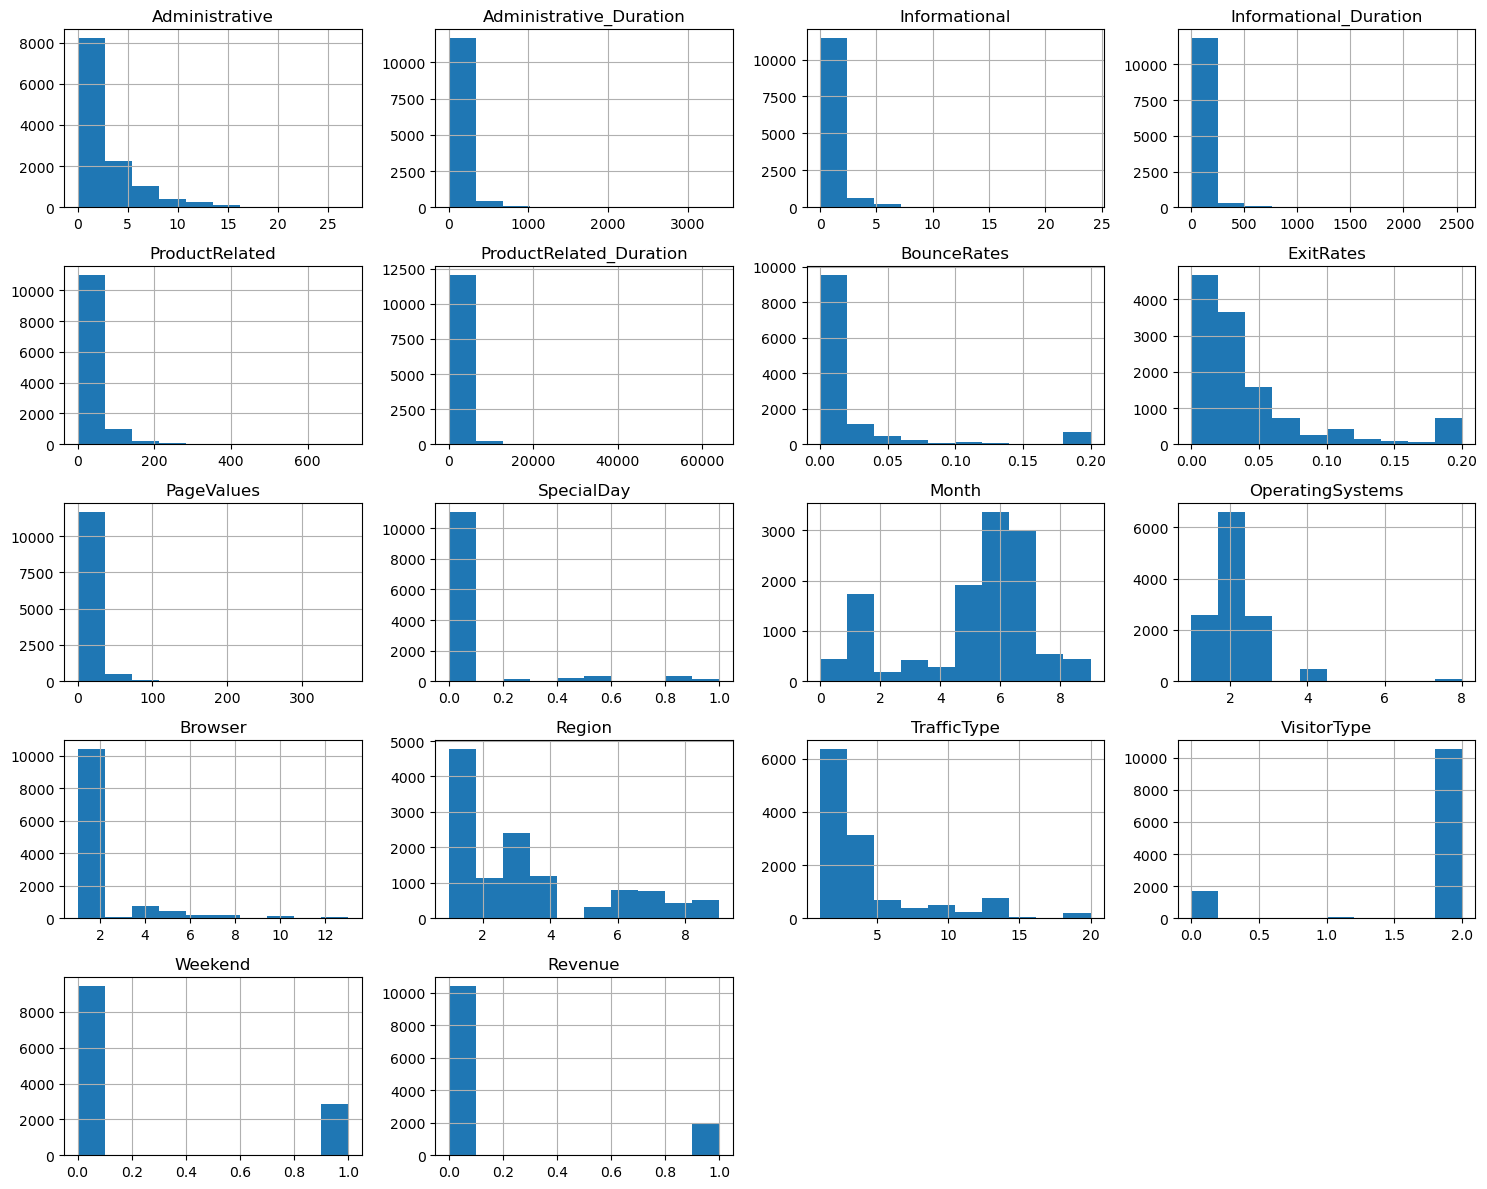

In [14]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()

## Train-Test Split

In [15]:
X = df.drop(['Revenue', 'Revenue_Label'], axis=1)
y = df['Revenue']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.27, random_state=101)

## Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Building

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Logistic Regression

In [19]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=350, random_state=101)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

XGBoot

In [21]:
xgb = XGBClassifier(n_estimators=350,max_depth=7,learning_rate=0.1,n_jobs=-1, random_state=101)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

## Model Evaluation

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
def evaluate(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

Evaluate model performance

In [24]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

--- Logistic Regression ---
Accuracy: 0.8864864864864865
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2815
           1       0.75      0.40      0.52       515

    accuracy                           0.89      3330
   macro avg       0.82      0.69      0.73      3330
weighted avg       0.88      0.89      0.87      3330

[[2745   70]
 [ 308  207]]
--- Random Forest ---
Accuracy: 0.9069069069069069
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      2815
           1       0.74      0.61      0.67       515

    accuracy                           0.91      3330
   macro avg       0.84      0.78      0.81      3330
weighted avg       0.90      0.91      0.90      3330

[[2708  107]
 [ 203  312]]
--- XGBoost ---
Accuracy: 0.8942942942942943
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2815
           1       0.68      0

Near Around Accuracy - 91% (Random Forest)

Precision & Recall show prediction quality

ROC-AUC score

In [25]:
from sklearn.metrics import roc_auc_score
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

ROC-AUC: 0.9322830191932953


ROC Curve

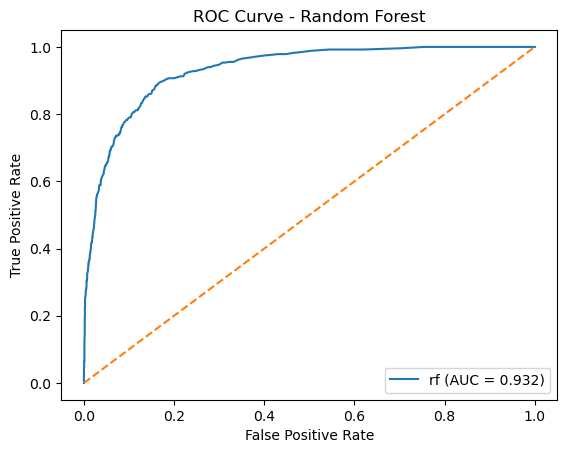

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_prob = rf.predict_proba(X_test)[:,1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
log_model = rf

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'rf (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()
plt.show()

High AUC → strong model

## Confusion Matrix
#### It shows: Correct predictions,False positives, False negatives

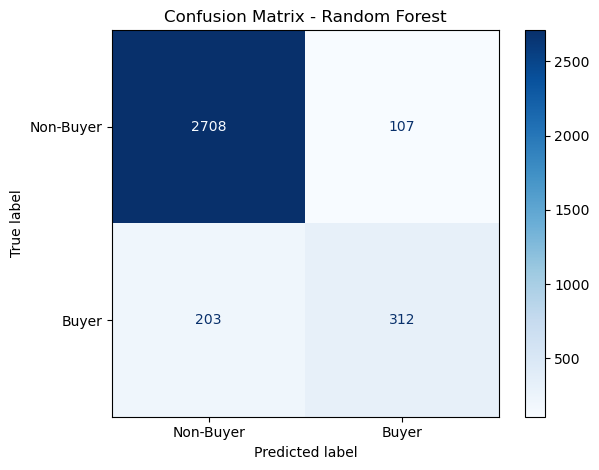

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Buyer', 'Buyer']
)

disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

## Feature Importance
#### Identify most impactful features

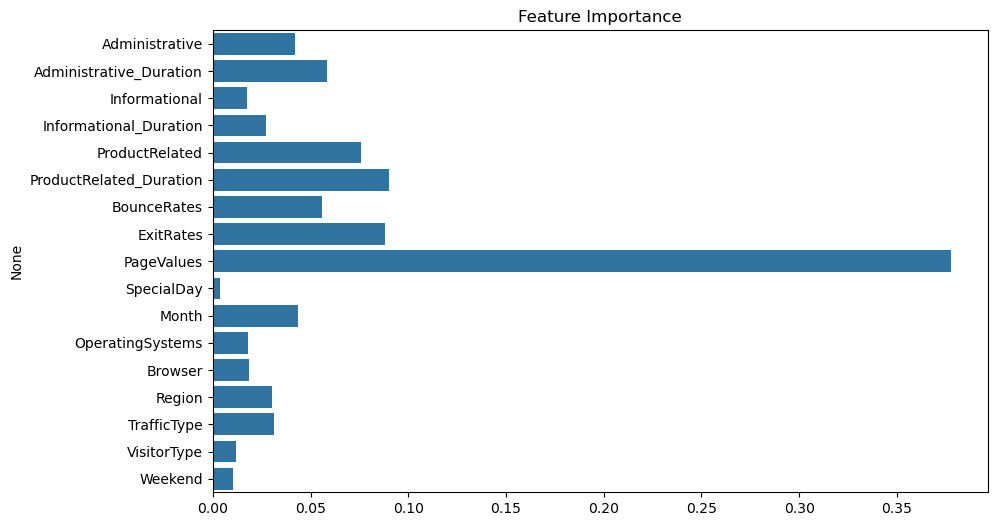

In [28]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

Top 6 Important features

In [29]:
# Create DataFrame
feat_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

# Filter features with importance > 0.05
important_features = feat_df[feat_df['importance'] > 0.05].sort_values(by='importance',ascending=False).reset_index(drop=True)
important_features

,feature,importance
0,PageValues,0.377572
1,ProductRelated_Duration,0.089935
2,ExitRates,0.088029
3,ProductRelated,0.075702
4,Administrative_Duration,0.058262
5,BounceRates,0.056040


1) Users who visit high-value pages (PageValues) and spend more time on product pages are much more likely to make a purchase.
2) High bounce and exit rates indicate users are leaving early, leading to loss of potential sales.
3) Businesses should improve website experience and optimize product/checkout pages to increase conversions.
4) Focus on returning users and better marketing strategies to capture more customers and boost revenue.